<a href="https://colab.research.google.com/github/v-c-sch/DSF-DCBP-Rep.-SCHV/blob/main/DSF_Mid_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DSF Midterm Project

---


###1. Answer background questions, and upload them to your github


**1.1 Which packages are available for ML? Describe the pros and cons and document the availability**

Common ML packages include Scikit-learn, TensorFlow, PyTorch, Keras, and XGBoost. Scikit-learn is easy to use but not suited for deep learning. TensorFlow and PyTorch support deep learning and GPU usage but are more complex. Keras is user-friendly but less flexible. XGBoost is fast and accurate but less interpretable. All are available via Python (pip/conda).


**1.2 What is Chembl? How do you access it?**

ChEMBL is a database of bioactive molecules with drug-like properties. It contains chemical structures, biological activity data and targetet proteins.
It can be accessed trough their website, the python API or the data sets can be downloaded directly.


**1.3 What is machine learning, and how does it differ from traditional programming?**

Machine learning is a method where computers learn patterns from data instead of being explicitly programmed. With programming the computers produce an output according to previousely given rules. Machine learning causes the computer to create rules itself given the data it received. The model made is then used to predict possible outcomes.


**1.4 What are the key concepts and techniques in machine learning?**

Key concepts in machine learning include features, which are the input variables used by the model, and labels, which represent the desired output. The process of training involves adjusting a model based on training data so that it can make accurate predictions. Important techniques include data splitting into training and testing sets, feature engineering, and model evaluation. Concepts such as overfitting and underfitting are also crucial, as they describe whether a model learns too much noise or too little information from the data.


**1.5 What are the different types of machine learning algorithms?**

Machine learning algorithms can be divided into three main categories. Supervised learning uses labeled data to train models for tasks such as classification and regression. Unsupervised learning works with unlabeled data and aims to find patterns or groupings, such as clustering. Reinforcement learning is a different approach in which an agent learns by interacting with an environment and receiving rewards or penalties.

**1.6 What are the common applications of machine learning?**

Machine learning is used in many fields. In chemistry and drug discovery, it helps predict biological activity of compounds. In everyday applications, it is used for image recognition, speech recognition, and recommendation systems such as those used by streaming platforms. It is also widely applied in finance for fraud detection and risk analysis.

**1.7 How do you evaluate the performance of a machine learning model?**

The performance of a machine learning model is evaluated using specific metrics that depend on the task. For classification problems, common metrics include accuracy, precision, recall, and the F1-score. Another important measure is the ROC-AUC score, which evaluates how well a model distinguishes between classes. The evaluation is typically performed on a test dataset that was not used during training to ensure that the model generalizes well to new data.

**1.8 How do you prepare data for use in a machine learning model?**

Data preparation is an essential step in machine learning. It involves cleaning the data by removing errors or missing values, transforming the data into a suitable format, and normalizing or scaling features if necessary. In cheminformatics, molecular structures are often converted into numerical representations such as fingerprints. The data is then split into training and testing sets to allow proper evaluation of the model.

**1.9 What are some common challenges in machine learning, and how can they be addressed?**

Machine learning faces several challenges. One common issue is overfitting, where a model performs well on training data but poorly on new data; this can be addressed using techniques such as regularization or cross-validation. Poor data quality can negatively impact performance and must be handled through careful cleaning and preprocessing. Imbalanced datasets can also be problematic and may require resampling techniques. Additionally, complex models can be difficult to interpret, so simpler models or explainability methods may be used.

**1.10 What are some resources and tools available to help you learn and practice machine learning?**

There are many resources available for learning machine learning. Online platforms such as Kaggle provide datasets and practical challenges. Educational platforms like Coursera offer structured courses. Documentation from libraries such as Scikit-learn is also very useful. In addition, tools like Google Colab allow users to run machine learning code in the cloud without needing powerful local hardware. GitHub is another important resource for exploring existing projects and sharing code.



---


**1. What is in the training set, how big is it?**

The training set comes from the file kinase.csv. I filtered the data so that it only contains compounds for the target CHEMBL2971. I kept only valid activity values in nM, removed invalid rows, and converted the activity values to pIC50. After cleaning, I kept the columns molecule_chembl_id, canonical_smiles, and pIC50, removed duplicates, and used up to 3000 molecules.

**2. What modifications do you need to do to the data set to perform the tutorial?**

I had to filter the dataset to one target, keep only valid nM values, remove missing or invalid rows, and convert the activity values to pIC50. I also renamed the smiles column to canonical_smiles, removed duplicates, and created molecular fingerprints from the SMILES strings.

**3. What is a test set? Any other types of set?**

A test set is data that is not used for training. It is used to check how well the model works on unseen data. In this project, I used 70% training data and 30% test data. Another common set is the validation set, which is used during training to monitor model performance. Here, the model used 10% of the training data as validation data.

This cell imports the required libraries for data handling, molecular fingerprints, machine learning, and plotting. It prepares the environment for the workflow.

In [ ]:
!pip -q install rdkit
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

This cell defines the file paths and creates the output folder.

In [ ]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "data"

### Data preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset cleaning and target selection

The original `kinase.csv` dataset contains measurements for multiple kinase targets and cannot be used directly with the T022 workflow, which expects a single target. Therefore, we first remove the unused index column, keep only valid activity values in nM, determine the most frequent target, and convert the activity values into pIC50.

This cell loads the kinase dataset, filters it for the selected target, keeps valid activity values, and converts them to pIC50.

In [ ]:
# Load training data from Google Drive
from pathlib import Path

DRIVE_DIR = Path("/content/drive/MyDrive/DSF/MidTermProject")
KINASE_FILE = DRIVE_DIR / "kinase.csv"
TEST_FILE = DRIVE_DIR / "test.csv"

df = pd.read_csv(KINASE_FILE)

# Drop useless index column if present
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Keep only valid activity values
df = df[df["standard_units"] == "nM"].copy()
df = df[df["standard_value"].notna()].copy()
df = df[df["standard_value"] > 0].copy()

# Show most common targets
target_counts = df["target_chembl_id"].value_counts()
print("Top 10 targets:")
print(target_counts.head(10))
print("\nMost common target:", target_counts.idxmax())
print("Count:", target_counts.max())

# Keep only the most common target
most_common_target = target_counts.idxmax()
df = df[df["target_chembl_id"] == most_common_target].copy()

# Convert nM to pIC50
df["pIC50"] = 9 - np.log10(df["standard_value"])

# Rename SMILES column to match tutorial style
df = df.rename(columns={"smiles": "canonical_smiles"})

# Keep only needed columns
chembl_df = df[["canonical_smiles", "pIC50", "molecule_chembl_id", "target_chembl_id"]].copy()

# Reset index
chembl_df = chembl_df.reset_index(drop=True)

print("\nShape of cleaned dataframe:", chembl_df.shape)
chembl_df.head()

Top 10 targets:
target_chembl_id
CHEMBL2971    5429
CHEMBL5145    5373
CHEMBL4005    5176
CHEMBL260     4914
CHEMBL2842    4218
CHEMBL2835    3940
CHEMBL5251    3933
CHEMBL2599    3601
CHEMBL4282    3560
CHEMBL267     3482
Name: count, dtype: int64

Most common target: CHEMBL2971
Count: 5429

Shape of cleaned dataframe: (5429, 4)


,canonical_smiles,pIC50,molecule_chembl_id,target_chembl_id
0,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902,CHEMBL388978,CHEMBL2971
1,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970,CHEMBL388978,CHEMBL2971
2,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.638272,CHEMBL388978,CHEMBL2971
3,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970,CHEMBL388978,CHEMBL2971
4,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,9.508638,CHEMBL388978,CHEMBL2971


In [ ]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (5429, 6)
<class 'pandas.core.frame.DataFrame'>
Index: 5429 entries, 614 to 84645
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  5429 non-null   object 
 1   standard_value      5429 non-null   float64
 2   standard_units      5429 non-null   object 
 3   target_chembl_id    5429 non-null   object 
 4   canonical_smiles    5429 non-null   object 
 5   pIC50               5429 non-null   float64
dtypes: float64(2), object(4)
memory usage: 296.9+ KB


In [ ]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,canonical_smiles,pIC50
614,CHEMBL388978,4.70,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902
615,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
616,CHEMBL388978,2.30,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.638272
617,CHEMBL388978,2.00,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.698970
618,CHEMBL388978,0.31,nM,CHEMBL2971,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,9.508638


This cell keeps only the important columns, removes duplicates, and creates a cleaned dataset.

In [ ]:
# Keep necessary columns
chembl_df = df[["molecule_chembl_id", "canonical_smiles", "pIC50"]].dropna()

# remove duplicates
chembl_df = chembl_df.drop_duplicates(subset=["molecule_chembl_id"])

print("Shape of cleaned dataframe:", chembl_df.shape)
chembl_df.head()

Shape of cleaned dataframe: (4791, 3)


,molecule_chembl_id,canonical_smiles,pIC50
614,CHEMBL388978,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902
1894,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,5.822464
1936,CHEMBL601719,C[C@@H](Oc1cc(-c2cnn(C3CCNCC3)c2)cnc1N)c1c(Cl)...,7.568636
2087,CHEMBL495727,O=C(Nc1c[nH]nc1-c1nc2ccc(CN3CCOCC3)cc2[nH]1)NC...,8.920819
2654,CHEMBL1092926,Fc1cc(-c2cccc3ncc(-c4cnn(C5CCNCC5)c4)nc23)cc(F...,8.136677


### Molecular fingerprints

This cell defines a function to convert SMILES strings into molecular fingerprints.

In [ ]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Convert a SMILES string into a fingerprint array.
    Returns None if the SMILES is invalid.
    """

    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol), dtype=float)

    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol), dtype=float)

    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol), dtype=float)

    print(f"Warning: unknown method '{method}', using MACCS instead.")
    return np.array(MACCSkeys.GenMACCSKeys(mol), dtype=float)

This cell generates fingerprints for all molecules and removes invalid entries.

In [ ]:
chembl_df["fingerprints_df"] = chembl_df["canonical_smiles"].apply(smiles_to_fp)

invalid_smiles = chembl_df["fingerprints_df"].isna().sum()
print("Invalid SMILES removed:", invalid_smiles)

chembl_df = chembl_df[chembl_df["fingerprints_df"].notna()].copy()
chembl_df = chembl_df.reset_index(drop=True)

print("Shape after fingerprinting:", chembl_df.shape)
chembl_df.head(3)

Invalid SMILES removed: 0
Shape after fingerprinting: (4791, 4)


,molecule_chembl_id,canonical_smiles,pIC50,fingerprints_df
0,CHEMBL388978,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,8.327902,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,5.822464,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,CHEMBL601719,C[C@@H](Oc1cc(-c2cnn(C3CCNCC3)c2)cnc1N)c1c(Cl)...,7.568636,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


After fingerprint generation, molecules with invalid SMILES are excluded. The remaining compounds are now represented as fixed-length numerical vectors and can be used as input for the neural network.

### Train/test split

The fingerprint vectors (`X`) are used as input features and the pIC50 values (`y`) as regression targets. We split the data into a training set and a test set so that the model can be trained on one part of the data and evaluated on unseen compounds.

This cell splits the data into training and test sets and converts the fingerprints into NumPy arrays.

In [ ]:
# Build X and y explicitly
X = np.array(list(chembl_df["fingerprints_df"]), dtype=float)
y = chembl_df[["pIC50"]].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

X shape: (4791, 167)
y shape: (4791, 1)
Shape of training data: (3353, 167)
Shape of test data: (1438, 167)


### Define neural network


This cell defines a neural network model with two hidden layers. It prepares the model for training and prediction.

In [ ]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

### Train the model


In [ ]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

This cell trains the neural network with different batch sizes and plots the training and test loss. It helps compare how the batch size affects model performance.

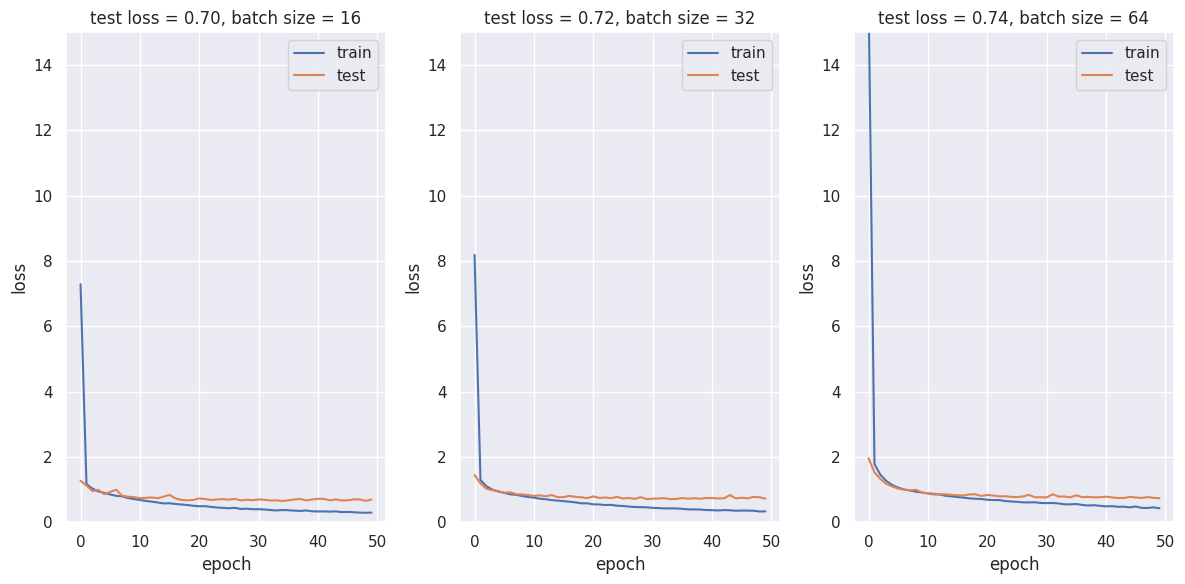

In [ ]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)

for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        x_train,
        y_train,
        batch_size=batch,
        validation_data=(x_test, y_test),
        verbose=0,
        epochs=nb_epoch,
    )

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, batch size = {batch}"
    )

plt.tight_layout()
plt.show()

This cell trains the model and saves the best weights during training. After training, the best saved weights are loaded again.

In [ ]:
# Save model checkpoints
filepath = DATA / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    filepath=str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit model
model = neural_network_model(layer1_size, layer2_size)
model.build((None, x_train.shape[1]))

model.fit(
    x_train,
    y_train,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=0,
)

# Load best saved weights
model.load_weights(filepath)

### Evaluation & prediction on test set


This cell evaluates the model on the test data. It prints the loss, MSE, and MAE to show the model performance.

In [ ]:
# Evaluate the model
print("Evaluate the model on the test data")
scores = model.evaluate(x_test, y_test, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 0.80
 mse (same as loss): 0.80
 mae: 0.67


The model is evaluated on the test set, which contains compounds that were not used during training. The reported loss, MSE, and MAE indicate how closely the predicted pIC50 values match the true pIC50 values on unseen data.

This cell uses the trained model to predict pIC50 values for the test data. It then prints the first five predicted values.

In [ ]:
# Predict pIC50 values on x_test data
y_pred = model.predict(x_test, verbose=0)

print("First 5 predicted pIC50 values:")
for value in y_pred[:5]:
    print(f"{value[0]:.2f}")

First 5 predicted pIC50 values:
9.58
8.32
10.98
7.76
6.20


### Scatter plot of predicted vs. true pIC50 values

The scatter plot compares the predicted pIC50 values with the true pIC50 values from the test set. A perfect model would place all points on the diagonal line, while deviations from that line indicate prediction errors.

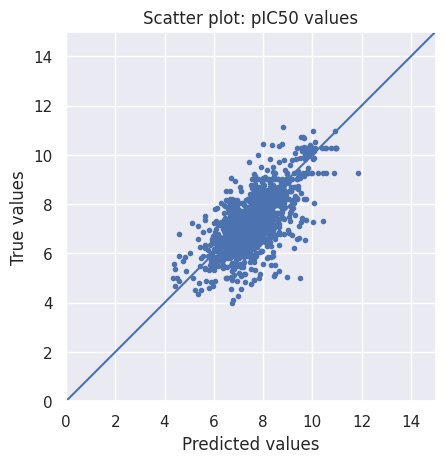

In [ ]:
# Scatter plot
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

### Prediction on external / unlabeled compounds

After training, the model is applied to a small external set of molecules for which no activity labels are provided in the notebook. The goal is to rank these compounds by predicted pIC50 and identify the most promising candidates.

Invalid test SMILES removed: 0
Shape of test dataframe after fingerprinting: (3, 3)


,id,canonical_smiles,fingerprints_df
0,1109053969,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1422188626,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2032016830,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."



Predictions for test.csv:


,id,canonical_smiles,predicted_pIC50
0,1109053969,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,4.927801
1,1422188626,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,3.599730
2,2032016830,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,5.549493



Saved predictions to: /content/drive/MyDrive/DSF/MidTermProject/test_predicted.csv

Top 3 molecules from test.csv:


,id,canonical_smiles,predicted_pIC50
2,2032016830,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...,5.549493
0,1109053969,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...,4.927801
1,1422188626,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...,3.599730


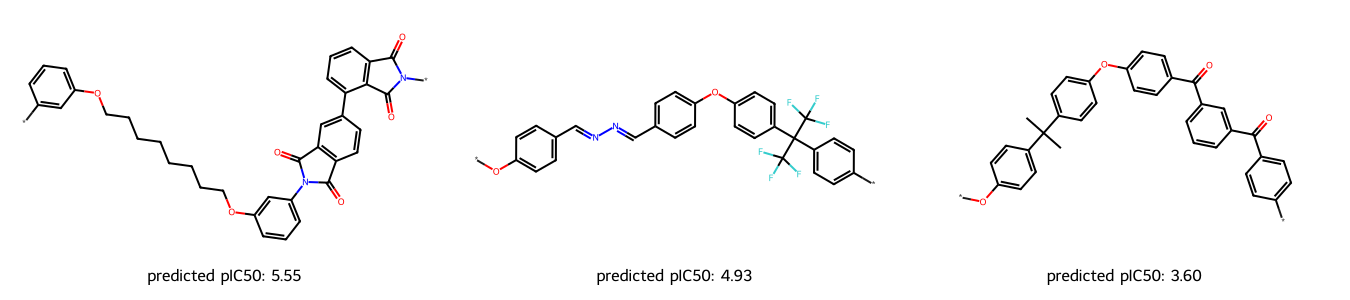

In [ ]:
# Load external/unlabeled test set from Google Drive
test_df = pd.read_csv(TEST_FILE)

# Keep original columns and rename SMILES for the workflow
test_df = test_df.rename(columns={"SMILES": "canonical_smiles"}).copy()

# Convert SMILES strings to fingerprints
test_df["fingerprints_df"] = test_df["canonical_smiles"].apply(smiles_to_fp)

# Remove invalid SMILES / failed fingerprints
invalid_test = test_df["fingerprints_df"].isna().sum()
print("Invalid test SMILES removed:", invalid_test)

test_df = test_df[test_df["fingerprints_df"].notna()].copy()
test_df = test_df.reset_index(drop=True)

print("Shape of test dataframe after fingerprinting:", test_df.shape)
display(test_df.head())

if test_df.empty:
    raise ValueError("No valid molecules remained in test_df after fingerprinting.")

# Convert to numpy array
X_test_external = np.array(list(test_df["fingerprints_df"]), dtype=float)

# Build model architecture
model = neural_network_model(layer1_size, layer2_size)

# IMPORTANT: build model before loading weights
model.build((None, X_test_external.shape[1]))

# Load saved weights
model.load_weights(DATA / "best_weights.weights.h5")

# Predict pIC50 values for test.csv
predictions = model.predict(X_test_external, verbose=0)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_test_df = test_df.join(predicted_pIC50)

print("\nPredictions for test.csv:")
display(predicted_test_df[["id", "canonical_smiles", "predicted_pIC50"]])

# Save predicted values back to the same Google Drive folder
output_file = DRIVE_DIR / "test_predicted.csv"
predicted_test_df.to_csv(output_file, index=False)

print(f"\nSaved predictions to: {output_file}")

# Select top 3 molecules
top3_drug = predicted_test_df.nlargest(3, "predicted_pIC50")
print("\nTop 3 molecules from test.csv:")
display(top3_drug[["id", "canonical_smiles", "predicted_pIC50"]])

# Draw molecule structures
from rdkit.Chem import Draw

highest_pIC50 = top3_drug["canonical_smiles"]
mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [f"predicted pIC50: {value:.2f}" for value in pIC50_EGFR]

img = Draw.MolsToGridImage(
    mols_EGFR,
    molsPerRow=3,
    subImgSize=(450, 300),
    legends=pIC50_values,
)

display(img)

The top three molecules are selected based on their predicted pIC50 values. Since these values are model predictions and not experimental measurements, they should be interpreted as candidate rankings rather than confirmed biological activity.


---

###5. Gain access to Ubelix

**5.1 What is Ubelix?**

Ubelix is the High Performance Computing unit of the university of bern
UBELIX is an acronym and stands for University of Bern Linux Cluster

**5.2 How do you gain access?**

By requesting access over the unibe support dialog window

**5.3 How do you submit a job?**

Every job submission starts with a resources allocation (nodes, cores, memory). An allocation is requested for a specific amount of time, and can be created using the salloc, sbatch commands. Whereas salloc and sbatch only create resource allocations, srun launches parallel tasks within such a resource allocation.

**5.4 Who can have access?**

The infrastructure is available to all University personnel for their scientific work. The cluster can also be used by students within a scope of a thesis or a course.

**5.5 What resources are available there?**

Currently, the UBELIX cluster runs around 280 compute nodes featuring ~15k CPU cores and ~180 GPUs with almost one million GPU cores.

---


#File transfer to Ubelix

For the Ubelix run, the necessary files were uploaded through the OnDemand website. I used the web-based interface to transfer the files directly from my PC to my Ubelix working directory. In particular, I uploaded the Python script t022.py and the dataset file kinase.csv. After that, I launched the training job on Ubelix and the generated output files were stored

#UBELIX Run

To run the training step on Ubelix, the original TeachOpenCADD T022 tutorial notebook was adapted into a standalone Python script called t022.py. The notebook-style workflow was converted into a batch-compatible script so it could be executed non-interactively on the cluster. Instead of running inside a Jupyter notebook, all steps were placed into a single Python file that loads the data, preprocesses it, trains the model, evaluates it, and saves the outputs automatically.

The following changes were made:



*   the code was changed from notebook cells into one executable Python script
*   the provided local file kinase.csv was used instead of the original   tutorial training set
*   the dataset was filtered to the target CHEMBL2971
*   the activity values were converted from nM to pIC50
*   the molecular features were generated as fingerprints from SMILES strings
*   the training model was implemented using MLPRegressor from scikit-learn
*   all outputs were saved automatically into a local data/ folder, including the trained model, predictions, the loss plot, and the top-molecule image


For the final run, the notebook code was converted into a Python script so it could be executed on the Ubelix cluster. Notebook-specific commands and interactive outputs were removed, and all file paths were adapted to the project folder structure. To reduce package requirements and make the setup easier on the cluster, the original TensorFlow/Keras model was replaced with a lighter scikit-learn MLP Regressor. The workflow stayed the same: data loading, preprocessing, fingerprint generation from SMILES, model training, evaluation, and prediction for external molecules. The script was submitted as a SLURM job, and the outputs were saved automatically as a model file, a CSV file with predictions, and image files for the training plot and top predicted molecules.

In [ ]:
"""
from pathlib import Path
from warnings import filterwarnings

filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt


# =========================================================
# Paths
# =========================================================
HERE = Path(__file__).resolve().parent
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)

KINASE_FILE = HERE / "kinase.csv"
TEST_FILE = HERE / "test.csv"
# =========================================================
# Load kinase data
# =========================================================
df = pd.read_csv(KINASE_FILE)

# one target only
df = df[df["target_chembl_id"] == "CHEMBL2971"].copy()

# keep only valid nM values
df = df[df["standard_units"] == "nM"].copy()
df = df[df["standard_value"] > 0].copy()

# convert nM to pIC50
df["pIC50"] = 9 - np.log10(df["standard_value"])

# rename smiles column to match notebook
df = df.rename(columns={"smiles": "canonical_smiles"})

# reset index
df = df.reset_index(drop=True)

print("Shape of dataframe:", df.shape)
print(df.head())

print("Shape of dataframe :", df.shape)
df.info()
print(df.head())


# =========================================================
# Keep necessary columns
# =========================================================
chembl_df = df[["molecule_chembl_id", "canonical_smiles", "pIC50"]].dropna()
chembl_df = chembl_df.drop_duplicates(subset=["molecule_chembl_id"])

print("Shape of cleaned dataframe:", chembl_df.shape)
print(chembl_df.head())


# =========================================================
# Fingerprint function
# =========================================================
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None
    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol), dtype=float)
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol), dtype=float)
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol), dtype=float)
    else:
        print(f"Warning: Wrong method specified: {method}. Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol), dtype=float)


chembl_df["fingerprints_df"] = chembl_df["canonical_smiles"].apply(smiles_to_fp)
chembl_df = chembl_df[chembl_df["fingerprints_df"].notna()].copy()

print("Shape of dataframe:", chembl_df.shape)
print(chembl_df.head(3))


# =========================================================
# Train/test split
# =========================================================
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"],
    chembl_df["pIC50"],
    test_size=0.3,
    random_state=42,
)

print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

X_train = np.array(list(x_train)).astype(float)
X_test = np.array(list(x_test)).astype(float)
y_train = y_train.values.astype(float)
y_test = y_test.values.astype(float)


# =========================================================
# Model
# =========================================================
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    batch_size=16,
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
)

model.fit(X_train, y_train)

# save trained model
joblib.dump(model, DATA / "best_model.joblib")


# =========================================================
# Training loss plot
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_)
plt.ylabel("loss")
plt.xlabel("iteration")
plt.title("Training loss")
plt.tight_layout()
plt.savefig(DATA / "training_loss_plot.png", dpi=300, bbox_inches="tight")
plt.close()


# =========================================================
# Evaluate
# =========================================================
y_pred_test = model.predict(X_test)

mse = np.mean((y_test - y_pred_test) ** 2)
mae = np.mean(np.abs(y_test - y_pred_test))

print("Evaluate the model on the test data")
print(f" loss: {mse:.2f}")
print(f" mse (same as loss): {mse:.2f}")
print(f" mae: {mae:.2f}")

for value in y_pred_test[:5]:
    print(f"{value:.2f}")


# =========================================================
# Predict molecules from test.csv
# =========================================================
test_df = pd.read_csv(TEST_FILE)

# Falls test.csv die Spalte "SMILES" hat:
test_df = test_df.rename(columns={"SMILES": "canonical_smiles"}).copy()

# Sicherheitscheck
if "canonical_smiles" not in test_df.columns:
    raise ValueError("test.csv must contain a column named 'SMILES' or 'canonical_smiles'.")

# Fingerprints erzeugen
test_df["fingerprints_df"] = test_df["canonical_smiles"].apply(smiles_to_fp)

# Ungültige SMILES entfernen
invalid_test = test_df["fingerprints_df"].isna().sum()
print(f"Invalid test SMILES removed: {invalid_test}")

test_df = test_df[test_df["fingerprints_df"].notna()].copy()
test_df = test_df.reset_index(drop=True)

print("Shape of test dataframe:", test_df.shape)
print(test_df.head(3))

if test_df.empty:
    raise ValueError("No valid molecules remained in test_df after fingerprinting.")

# Feature-Matrix
X_external = np.array(list(test_df["fingerprints_df"])).astype(float)

# Vorhersage
predictions = model.predict(X_external)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = test_df.join(predicted_pIC50)

print("\nPredictions:")
print(predicted_pIC50_df)

# Speichern
predicted_pIC50_df.to_csv(DATA / "test_predicted.csv", index=False)
print(f"Saved predictions to: {DATA / 'test_predicted.csv'}")


# =========================================================
# Top 3 molecules and image
# =========================================================
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
print("\nTop 3 molecules from test.csv:")
print(top3_drug[["canonical_smiles", "predicted_pIC50"]])

highest_pIC50 = top3_drug["canonical_smiles"]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [f"predicted pIC50: {value:.2f}" for value in pIC50_EGFR]

img = Draw.MolsToGridImage(
    mols_EGFR,
    molsPerRow=3,
    subImgSize=(450, 300),
    legends=pIC50_values,
)

img.save(str(DATA / "top3_molecules.png"))
print(f"Saved image to: {DATA / 'top3_molecules.png'}")
print(f"Saved model to: {DATA / 'best_model.joblib'}")
"""

'\nfrom pathlib import Path\nfrom warnings import filterwarnings\n\nfilterwarnings("ignore")\n\nimport joblib\nimport pandas as pd\nimport numpy as np\nfrom rdkit import Chem\nfrom rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.neural_network import MLPRegressor\nimport matplotlib.pyplot as plt\n\n\n# =========================================================\n# Paths\n# =========================================================\nHERE = Path(__file__).resolve().parent\nDATA = HERE / "data"\nDATA.mkdir(exist_ok=True)\n\nKINASE_FILE = HERE / "kinase.csv"\nTEST_FILE = HERE / "test.csv"\n# =========================================================\n# Load kinase data\n# =========================================================\ndf = pd.read_csv(KINASE_FILE)\n\n# one target only\ndf = df[df["target_chembl_id"] == "CHEMBL2971"].copy()\n\n# keep only valid nM values\ndf = df[df["standard_units"] == "nM"].copy()\ndf = 

#UBELIX Submission

In [ ]:
"""
#!/bin/bash
#SBATCH --account=gratis
#SBATCH --partition=epyc2
#SBATCH --qos=job_gratis
#SBATCH --job-name="t022"
#SBATCH --time=01:00:00
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=4
#SBATCH --mem=8G
#SBATCH --output=slurm-%j.out
module load Anaconda3/2024.02-1
cd "/storage/homefs/vs23h068/DSF MTP"
conda run -n t022rf python t022.py
"""

'\n#!/bin/bash\n#SBATCH --account=gratis\n#SBATCH --partition=epyc2\n#SBATCH --qos=job_gratis\n#SBATCH --job-name="t022"\n#SBATCH --time=01:00:00\n#SBATCH --nodes=1\n#SBATCH --ntasks=1\n#SBATCH --cpus-per-task=4\n#SBATCH --mem=8G\n#SBATCH --output=slurm-%j.out\nmodule load Anaconda3/2024.02-1\ncd "/storage/homefs/vs23h068/DSF MTP"\nconda run -n t022rf python t022.py\n'

### UBELIX run output

The following output shows that the preprocessing, training, evaluation, and prediction steps were successfully executed on the Ubelix cluster.

In [ ]:
"""
cat slurm-1869100.out
Shape of dataframe: (5429, 7)
   Unnamed: 0  ...     pIC50
0         614  ...  8.327902
1         615  ...  8.698970
2         616  ...  8.638272
3         617  ...  8.698970
4         618  ...  9.508638
[5 rows x 7 columns]
Shape of dataframe : (5429, 7)
<class 'pandas.DataFrame'>
RangeIndex: 5429 entries, 0 to 5428
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          5429 non-null   int64
 1   molecule_chembl_id  5429 non-null   str
 2   standard_value      5429 non-null   float64
 3   standard_units      5429 non-null   str
 4   target_chembl_id    5429 non-null   str
 5   canonical_smiles    5429 non-null   str
 6   pIC50               5429 non-null   float64
dtypes: float64(2), int64(1), str(4)
memory usage: 297.0 KB
   Unnamed: 0  ...     pIC50
0         614  ...  8.327902
1         615  ...  8.698970
2         616  ...  8.638272
3         617  ...  8.698970
4         618  ...  9.508638
[5 rows x 7 columns]
Shape of cleaned dataframe: (4791, 3)
   molecule_chembl_id  ...     pIC50
0        CHEMBL388978  ...  8.327902
9        CHEMBL509032  ...  5.822464
10       CHEMBL601719  ...  7.568636
11       CHEMBL495727  ...  8.920819
14      CHEMBL1092926  ...  8.136677
[5 rows x 3 columns]
Shape of dataframe: (4791, 4)
   molecule_chembl_id  ...                                    fingerprints_df
0        CHEMBL388978  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
9        CHEMBL509032  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
10       CHEMBL601719  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
[3 rows x 4 columns]
Shape of training data: (3353,)
Shape of test data: (1438,)
Evaluate the model on the test data
loss: 0.71
 mse (same as loss): 0.71
 mae: 0.63
9.60
7.54
9.57
6.68
5.96
Invalid test SMILES removed: 0
Shape of test dataframe: (3, 3)
           id  ...                                    fingerprints_df
0  1109053969  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1  1422188626  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2  2032016830  ...  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
[3 rows x 3 columns]
Predictions:
           id  ... predicted_pIC50
0  1109053969  ...        4.470278
1  1422188626  ...        3.977701
2  2032016830  ...        4.991442
[3 rows x 4 columns]
Saved predictions to: /storage/homefs/vs23h068/DSF MTP/data/test_predicted.csv
Top 3 molecules from test.csv:
                                    canonical_smiles  predicted_pIC50
2  *c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...         4.991442
0  *Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...         4.470278
1  *Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...         3.977701
Saved image to: /storage/homefs/vs23h068/DSF MTP/data/top3_molecules.png
Saved model to: /storage/homefs/vs23h068/DSF MTP/data/best_model.joblib
"""

"\ncat slurm-1869100.out\nShape of dataframe: (5429, 7)\n   Unnamed: 0  ...     pIC50\n0         614  ...  8.327902\n1         615  ...  8.698970\n2         616  ...  8.638272\n3         617  ...  8.698970\n4         618  ...  9.508638\n[5 rows x 7 columns]\nShape of dataframe : (5429, 7)\n<class 'pandas.DataFrame'>\nRangeIndex: 5429 entries, 0 to 5428\nData columns (total 7 columns):\n #   Column              Non-Null Count  Dtype  \n---  ------              --------------  -----  \n 0   Unnamed: 0          5429 non-null   int64  \n 1   molecule_chembl_id  5429 non-null   str    \n 2   standard_value      5429 non-null   float64\n 3   standard_units      5429 non-null   str    \n 4   target_chembl_id    5429 non-null   str    \n 5   canonical_smiles    5429 non-null   str    \n 6   pIC50               5429 non-null   float64\ndtypes: float64(2), int64(1), str(4)\nmemory usage: 297.0 KB\n   Unnamed: 0  ...     pIC50\n0         614  ...  8.327902\n1         615  ...  8.698970\n2        

#Top 3 Molecules

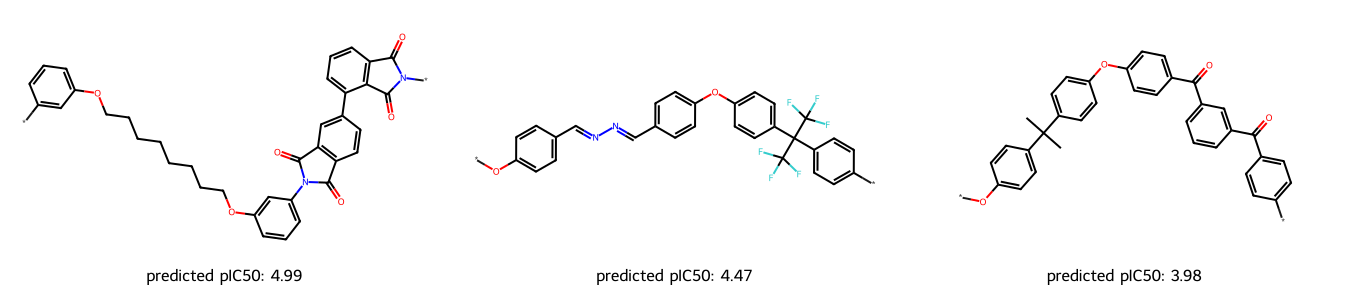

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# y in 1D umwandeln
y_train_flat = np.ravel(y_train)
y_test_flat = np.ravel(y_test)

results = []

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train_flat)
y_pred_rf = rf_model.predict(x_test)

rf_mae = mean_absolute_error(y_test_flat, y_pred_rf)
rf_mse = mean_squared_error(y_test_flat, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test_flat, y_pred_rf)

results.append({
    "Model": "Random Forest",
    "MAE": rf_mae,
    "MSE": rf_mse,
    "RMSE": rf_rmse,
    "R2": rf_r2
})

# SVM
svm_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1
)

svm_model.fit(x_train, y_train_flat)
y_pred_svm = svm_model.predict(x_test)

svm_mae = mean_absolute_error(y_test_flat, y_pred_svm)
svm_mse = mean_squared_error(y_test_flat, y_pred_svm)
svm_rmse = np.sqrt(svm_mse)
svm_r2 = r2_score(y_test_flat, y_pred_svm)

results.append({
    "Model": "SVM",
    "MAE": svm_mae,
    "MSE": svm_mse,
    "RMSE": svm_rmse,
    "R2": svm_r2
})

# Neural Network (Colab)
colab_mse = 0.68
colab_mae = 0.62
colab_rmse = np.sqrt(colab_mse)

results.append({
    "Model": "Neural Network (Colab)",
    "MAE": colab_mae,
    "MSE": colab_mse,
    "RMSE": colab_rmse,
    "R2": np.nan
})

# Neural Network (Ubelix)
ubelix_mse = 0.71
ubelix_mae = 0.63
ubelix_rmse = np.sqrt(ubelix_mse)

results.append({
    "Model": "Neural Network (Ubelix)",
    "MAE": ubelix_mae,
    "MSE": ubelix_mse,
    "RMSE": ubelix_rmse,
    "R2": np.nan
})

# Vergleichstabelle
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("Model comparison:")
print(results_df)

best_model = results_df.iloc[0]["Model"]
print(f"\nBest model based on RMSE: {best_model}")

Model comparison:
                     Model       MAE       MSE      RMSE        R2
0                      SVM  0.565698  0.579995  0.761574  0.533394
1            Random Forest  0.579990  0.625131  0.790652  0.497082
2   Neural Network (Colab)  0.620000  0.680000  0.824621       NaN
3  Neural Network (Ubelix)  0.630000  0.710000  0.842615       NaN

Best model based on RMSE: SVM


#Model Performance Comparison: SVM, Random Forest, and Neural Network
Among all tested models, SVM showed the best performance, with the lowest MAE, MSE, and RMSE, and the highest R². Random Forest ranked second, while both neural-network runs performed worse. This indicates that for this dataset, classical machine-learning methods outperformed the neural-network approach.